shwarzschild radius (m): 12094622799.999996


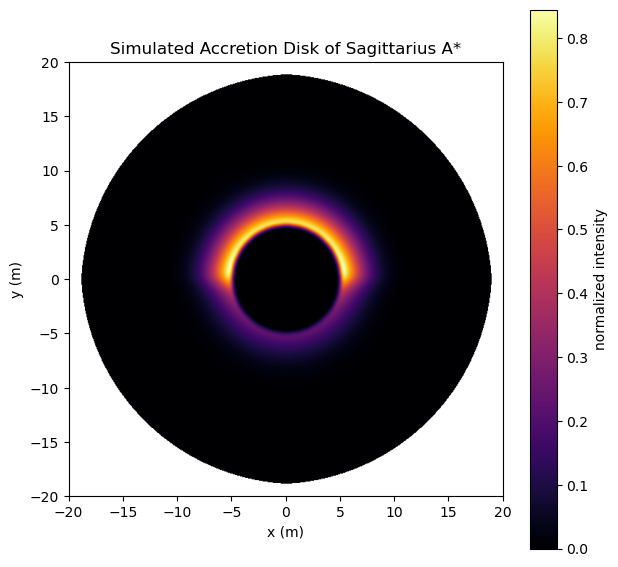

In [10]:
#STEP 1 --> IMPORT PACKAGES
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams['figure.figsize'] = (6,6)

#STEP 2 --> ESTABLISH CONTSTANTS, DATA, AND PARAMETERS

#physical constants + black hole parameters
G = 6.674 * 10 ** -11     #gravity constant (m^3, kg^-1, s^-2)
c = 3e8     #speed of light (m/s)
M_sun = 1.989e30     #solar mass (kg)
M_SagA = 4.1e6 * M_sun     #mass of Sagittarius A (kg)
rs = 2 * G * M_SagA / c**2     #Schwarzschild Radius = (2GM/c^2)
print("shwarzschild radius (m):", rs)

#simulation grid
r_inner = 3 * rs     #this represents the inner edge of the disk near ISCO, its 3 because that is the most stable circular orbit
                     # for a non-spinning black hole
r_outer = 40 * rs     #this represent the outer edge of the disk, its 40 because thats a safe distance for strong emmision
N = 500     #numer of radial points
r = np.linspace(r_inner, r_outer, N)     #dinstance from the black hole center
dr = r[1] - r[0]     #spacing between radial points

#angular grid
theta = np.linspace(0, 2*np.pi, 300)     #angular coordinate around the disk
R, T = np.meshgrid(r, theta)     #R is radial coordinate of the 2D grid and T is the agular position at each point

#initial density
r_peak = 6 * rs     #radius where the most material is concentrated in the black hole
width = 2 * rs     #spread of the disk
sigma = np.exp(-(r-r_peak)**2) / (2* width**2)     #surface density

#temperature profile (hotter near the black hole & cooler the farther away it is)
T_profile = (r/rs)**(-0.75)     

#emission model
intensity = sigma * T_profile**4     #emitted radiation instensity

#expand to a 2D disk
Z = np.tile(intensity, (len(theta), 1))     #brightness at each point in the disk via repetiiton of input array

#black hole shadow
#Z[R < 5 * rs] = 0     #just removes emission inside the shadow region since the black hole is you know a black hole

#convert to cartesian coordinates from polar
x = np.linspace(-20, 20, 600)     #x-coordinates accross the disk
y = np.linspace(-20, 20, 600)     #y-coordinates accorss the disk
X_plot, Y_plot = np.meshgrid(x, y)     #transforms 1D vectors into coordinate matrices

R_plot = np.sqrt(X_plot**2 + Y_plot**2)     #radial distance from black hole center
T_plot = np.arctan(Y_plot, X_plot)     #angular position
def compute_intensity(R, T):
    """
    computes the emission intensity of the accretion disk, 
    Parameters
    --------------
    R : 2D array
        Radial distance from the black hole (in units of rs).
    T : 2D array
        Angular coordinate (radians).
    Returns
    --------------
    Z : 2D array
        Normalized intensity map of the accretion disk.
    """
    #------------- Surface density - where matter is concentrated
    r_peak = 6 #chosen based on data observation
    width = 2
    sigma_plot = np.exp(-((R_plot - r_peak)**2) / (2 * width**2))
    #------------- Temperature profile (hotter closer to the black one gets, colder the farther from the black hole)
    T_profile_plot = np.zeros_like(R_plot)
    mask = R_plot > 0
    T_profile_plot[mask] = R_plot[mask]**(-0.75)
    #------------- Emmission model - combines density and temperature
    intensity_plot = sigma_plot * T_profile_plot**4
    #------------- Doppler boosting - brightens the side moving toward the observer
    beta = 0.9     #velocity/speed of light approximation CHANGED 0.6 to 0.9
    doppler = 1 + beta * np.cos(T_plot - np.pi/4) 
    Z_plot = intensity_plot * doppler_plot
    #------------- Black hole shadow - removes emission ~5 rs inside
    Z_plot[R_plot < 5] = 0
    Z_plot[R_plot > 20] = np.nan
    Z_plot = Z_plot / np.nanmax(Z_plot) #normalizes for visualization
    return Z 

from scipy.ndimage import gaussian_filter
Z_plot = gaussian_filter(Z_plot, sigma=2) #this is a little extra I decided to add to give my image a grainy, smoother image
#I thought it would be cool to make this image look more like a telescope image. You know, add some flavor

#STEP 4 --> PLOT DISK
def plot_disk(Z):
    """
    Plots accretion disk intensity map
    Parameters
    --------------
    Z: 2D array
        normalized intensity values to display
    Returns
    --------------
    none
    """
    plt.figure(figsize=(7,7))
    plt.imshow(
        Z_plot, 
        extent=[-20, 20, -20, 20],
        origin='lower', 
        cmap='inferno'
    )
    plt.colorbar(label='normalized intensity')
    plt.gca().set_aspect('equal')
    plt.title('Simulated Accretion Disk of Sagittarius A*')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.show()

#STEP 5 --> RUN IT
Z = compute_intensity(R, T)
plot_disk(Z)

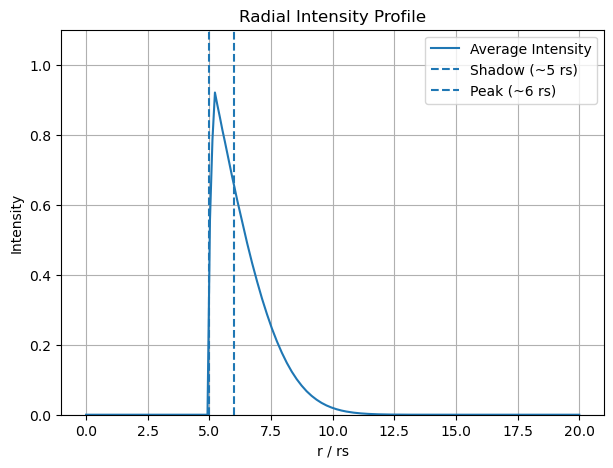

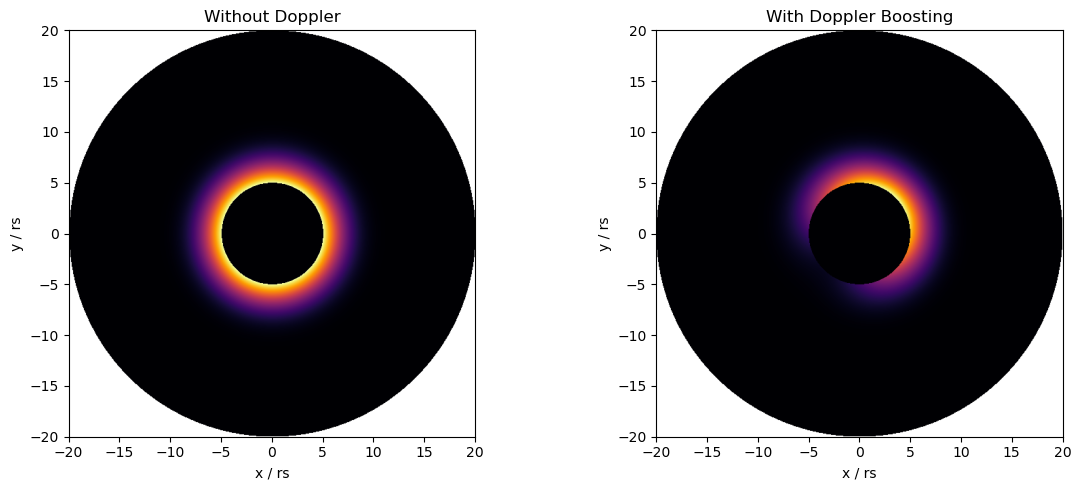

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#STEP 1 --> BUILD CARTESIAN GRID USING SAME DATA 
x = np.linspace(-20, 20, 600)
y = np.linspace(-20, 20, 600)
X_plot, Y_plot = np.meshgrid(x, y)

R_plot = np.sqrt(X_plot**2 + Y_plot**2)
T_plot = np.arctan2(Y_plot, X_plot)

#STEP 2 --> IMPORT DISK PHYSIS USING SAME DATA
r_peak = 6
width = 2

#surface density
sigma_plot = np.exp(-((R_plot - r_peak)**2) / (2 * width**2))

#temp profile
T_profile_plot = np.zeros_like(R_plot)
mask = R_plot > 0 
T_profile_plot[mask] = R_plot[mask]**(-0.75)

#intensity
intensity_plot = sigma_plot * T_profile_plot**4

Z_profile = intensity_plot.copy()
Z_profile[R_plot < 5] = 0
Z_profile[R_plot > 20] = np.nan
Z_profile = Z_profile / np.nanmax(Z_profile)

#STEP 3 --> SUPPORTING PLOT 1: RADIAL INTENSITY PROFILE
def plot_radial_intensity(R_plot, Z_profile):
    """
    Computes and plots the radial intensity profile of the accretion disk

    Paramters
    --------------
    R_plot: 2D array
        Radial distance from the black hole (in units of rs) for each grid point
    Z_profile: 2D array
        corrected intensity map after applying the black hole shadow and outer disk mask
    Returns  
    --------------
    none
        displays the plot of average intensity as a function of the radius
    """
    #-------------- defines the of range of radii to sample the disk structure - displays brightness changes relative to distance
    r_vals = np.linspace(0, 20, 200) 
    intensity_radial = []

    #-------------- loops through each radius and computes the average intensity in a thin ring
    #converts 2D image into a 1D radial profile
    for rv in r_vals:
        if rv < 5:
            intensity_radial.append(0)
            continue
        ring_mask = (R_plot > rv - 0.2) & (R_plot < rv + 0.2) #selects pixels within a small radial ring
        values = Z_profile[ring_mask]
        values = values[np.isfinite(values)]
        if len(values) > 0:
            intensity_radial.append(np.nanmean(values))
        else:
            intensity_radial.append(0)
            
        #intensity_radial.append(np.nanmean(intensity_plot[ring_mask])) #average intensity in the ring
            #nanmean --> avoids outside disk
    intensity_radial = np.array(intensity_radial)
    #-------------- plotting the graph
   
    #plots the radial intensity profile
    plt.figure(figsize=(7, 5))
    plt.plot(r_vals, intensity_radial, label='Average Intensity')

    #marks physically important radii
    plt.axvline(5, linestyle='--', label='Shadow (~5 rs)') #corresponds to the black hole's shadow
    plt.axvline(6, linestyle='--', label='Peak (~6 rs)') #corresponds to the emission peak

    plt.xlabel('r / rs')
    plt.ylabel('Intensity')
    plt.title('Radial Intensity Profile')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True)
    
    plt.show ()

#STEP 4 --> SUPPORTING PLOT 2: DOPPLER COMPARISON
def plot_doppler_comparison_(R_plot, T_plot, intenstity_plot):
    """
    Compares the disk appearance with or without Doppler boosting
   
    Parameters
    --------------
    R_plot: 2D array
          Radial distance from the black hole (in units of rs) for each grid point
    T_plot: 2D array
        angular coordinate for each grid point (radians)
    intensity_plot: 2D array
        intensity values across the disk before Doppler effects

    Returns
    --------------
    None
        displays side-by-side images of the accretion disk with and without Doppler boosting
    """
    #-------------- No Doppler
    Z_no_doppler = intensity_plot.copy() #purely symmetric representation of the brightness depending on radius only
    Z_no_doppler[R_plot < 5] = 0 #removes emission inside the black hole
    Z_no_doppler[R_plot > 20] = np.nan #removes outside values for a cleaner representation
    Z_no_doppler = Z_no_doppler / np.nanmax(Z_no_doppler) #creates max brightness as 1

    #-------------- With Doppler
    beta = 0.9
    doppler = 1 + beta * np.cos(T_plot - np.pi/4) #brightens material moving closer to the black hole

    Z_with_doppler = intensity_plot * doppler

    #applies same shadow/masking as with no doppler
    Z_with_doppler[R_plot < 5] = 0
    Z_with_doppler[R_plot > 20] = np.nan

    Z_with_doppler = Z_with_doppler / np.nanmax(Z_with_doppler) #normalizes again

    #-------------- plotting the graph 
    plt.figure(figsize=(12,5))

    #symmetric disk
    plt.subplot(1,2,1)
    plt.imshow(
        Z_no_doppler,
        extent=[-20,20,-20,20],
        origin='lower',
        cmap='inferno'
    )
    plt.title('Without Doppler')
    plt.xlabel('x / rs')
    plt.ylabel('y / rs')
    plt.gca().set_aspect('equal')
    #asymmetric disk
    plt.subplot(1,2,2)
    plt.imshow(
        Z_with_doppler,
        extent=[-20, 20, -20, 20],
        origin='lower',
        cmap='inferno'
    )
    plt.title('With Doppler Boosting')
    plt.xlabel('x / rs')
    plt.ylabel('y / rs')
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show

plot_radial_intensity(R_plot, Z_profile)
plot_doppler_comparison_(R_plot, T_plot, intensity_plot)

**README.md** 

**Simmulating the Accretion Disk of Sagittarius A**

This project uses data provided by the Event Horizon Telescope (EHT) and NASA archives to create a 2D image of Sag A*'s accretion disk.

**Description**

The EHT is a global, Earth-sized vitural observatory that uses data from multiple radio observatories worldwide to collect data. In doing so, the data provided has unparalleled angular resolution, ultimately allowed for clear images, and data, from deep space to be aquired. Using the data the EHT provided about Sagittarius A (Sag A*), the supermassive black hole at the center of the beloved Milky Way, combined with critial physical equations, I have coded a 2D image of the accretion disk surrounding Sag A*. Additionally, I also created a graph analyzing the radial intensity of the black hole, displaying a 1D curve of emission relative to the black hole, as well as two other 2D simulated images of the accretion disk, one with doppler boosting and one without, to further commuinicate both emission and the physical asymmetry of the disk itself. 

**Getting Started**
**Dependencies**

This project was performed on a Macbook. The sites used were GitHub, VS code, terminal, and Jupyter Notebook via Anaconda. 
The python packages used to interperate data/equations, as well as develop the graphs/simulations were Numpy, SciPy, and Matplotlib.

**Executing Program**

In order to run this program, follow the steps below:
1. Open this notebook in Jupyter Lab
2. Run all cells from top to bottom
3. The final output displayed will be the coded accretion disk, the intensity profile, and the two doppler comparisons

**Disclaimer**

This project contains a few limitations in regards to the complete accuracy of a 2D simulation of an accretion disk due to the time given, as well as knowledge restraints. What this simulation does not include is full general relativity, magnetic field modeling, or light bending. 

**References**

Event Horizon Telescope: https://ui.adsabs.harvard.edu/abs/2022ApJ...930L..12E/abstract 
Accretion disk physics: https://www.astro.princeton.edu/~gk/A403/disk.pdf
